/Users/dmiwu/work/PythonProject/QuantTest/factor_stock/个人投研之因子分析/Crypto/data/factor_data
                            volatility_efficiency_20d  volume_stability_20d  \
volatility_efficiency_20d                    1.000000             -0.048170   
volume_stability_20d                        -0.048170              1.000000   
alpha41_geometric_price                      0.750869             -0.038885   
alpha42_vwap_ratio                          -0.749736              0.035932   
rsi_cross_sectional                          0.749074             -0.035260   
accumulated_buy_sell_ratio                   0.597908             -0.066666   

                            alpha41_geometric_price  alpha42_vwap_ratio  \
volatility_efficiency_20d                  0.750869           -0.749736   
volume_stability_20d                      -0.038885            0.035932   
alpha41_geometric_price                    1.000000           -0.955609   
alpha42_vwap_ratio                        -0.955609      

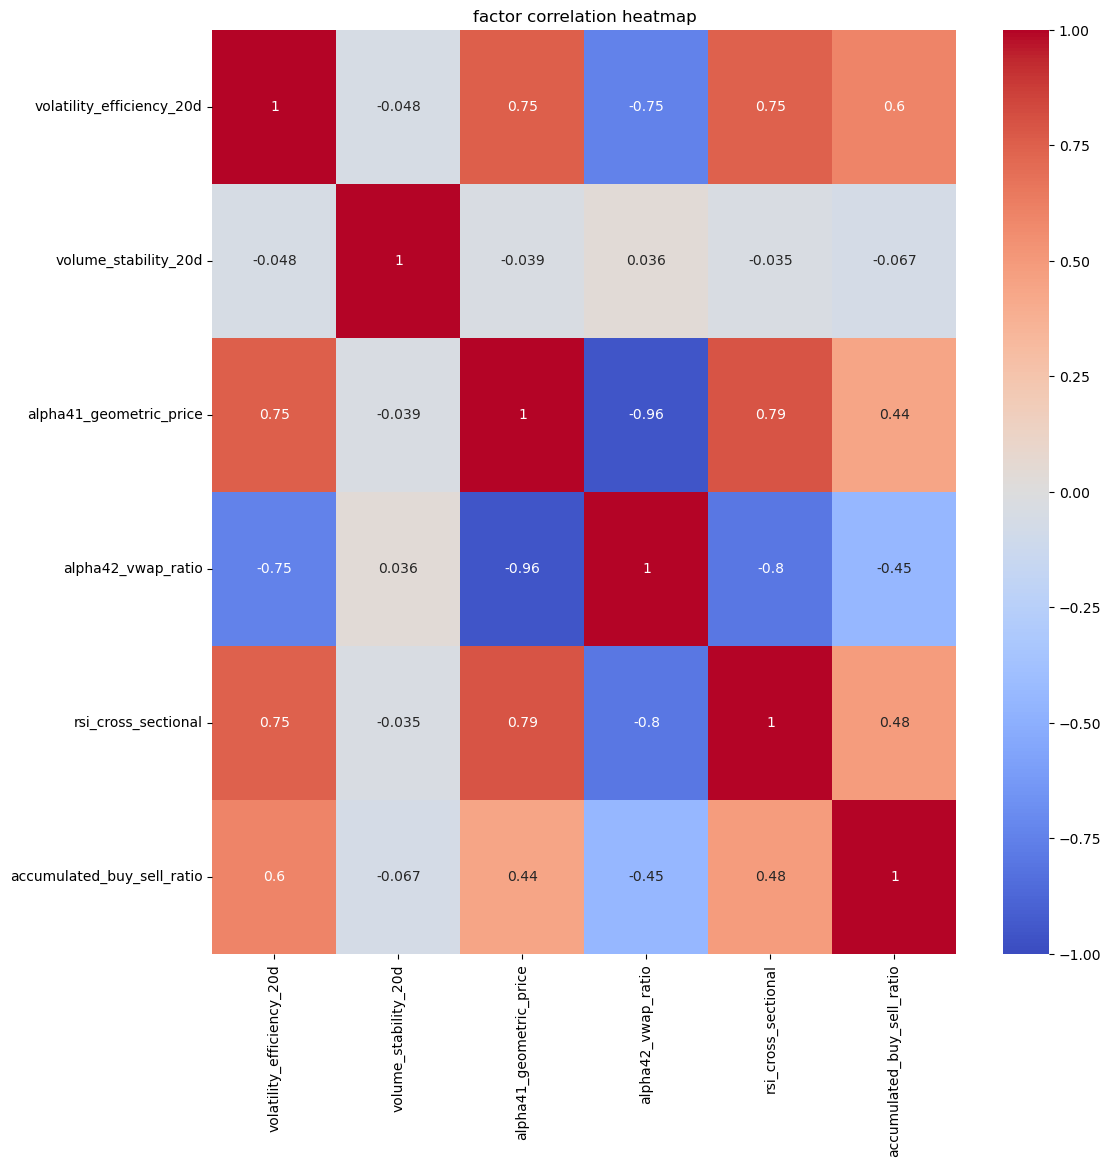

In [5]:
import pandas as pd
import os

# 获取当前 notebook 的工作目录
current_dir = os.getcwd()
factor_data_dir = os.path.join(os.path.dirname(current_dir), "data", "factor_data")
print(factor_data_dir)

# 因子文件及其对应的列名
factor_files = {
    "volatility_efficiency_20d": "volatility_efficiency_20d_rebalance10d_20250819.csv",
    "volume_stability_20d": "volume_stability_20d_rebalance10d_20250819.csv",
    "alpha41_geometric_price": "alpha41_geometric_price_20250819.csv", 
    "alpha42_vwap_ratio": "alpha42_vwap_ratio_20250819.csv", 
    "rsi_cross_sectional": "rsi_cross_sectional_14d_rebalance5d_20250819.csv",
    "accumulated_buy_sell_ratio": "accumulated_buy_sell_ratio_20d_rebalance10d_20250819.csv",
}

dfs = []
for factor, filename in factor_files.items():
    path = os.path.join(factor_data_dir, filename)
    df = pd.read_csv(path)
    df = df.rename(columns={'factor': factor})
    dfs.append(df[['date', 'instrument', factor]])

# 依次合并
from functools import reduce
df_merged = reduce(lambda left, right: pd.merge(left, right, on=['date', 'instrument'], how='inner'), dfs)

# 只保留因子列
factor_cols = list(factor_files.keys())
corr_matrix = df_merged[factor_cols].corr(method='pearson')
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("factor correlation heatmap")
plt.show()